# 🤖 E-Sports Biometrics: Baseline Machine Learning Model

Welcome to the baseline modeling notebook! 

In this notebook, we will build a foundational machine learning model to predict **`Match_Outcome` (Win/Loss)** based on a player's physiological and environmental biometrics. This will serve as a baseline score that you can try to beat using more advanced techniques (like XGBoost, LightGBM, or Neural Networks)!

### Notebook Structure:
1. **Data Loading & Preprocessing:** Cleaning missing values and encoding categorical features.
2. **Train/Test Split:** Preparing our data for modeling.
3. **Baseline Model Training:** Training a Random Forest Classifier.
4. **Model Evaluation:** Checking Accuracy, Precision, Recall, and Confusion Matrix.
5. **Feature Importance:** Discovering which biometrics matter most for winning.

---

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sarveshchhetri/e-sports-biometrics-and-performance/esports_gaming_biometrics_250k.csv
/kaggle/input/datasets/sarveshchhetri/e-sports-biometrics-and-performance/data_dictionary.csv


In [2]:
# import required libraries
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

# 1. Data loading and preprocessing

In [3]:
# load the dataset
df = pd.read_csv('/kaggle/input/datasets/sarveshchhetri/e-sports-biometrics-and-performance/esports_gaming_biometrics_250k.csv')

In [4]:
# handle missing value (using median)
df['Screen_Brightness'] = df['Screen_Brightness'].fillna(df['Screen_Brightness'].median())
df['HRV_Score'] = df['HRV_Score'].fillna(df['HRV_Score'].median())

# drop unnecessary identifiers
df = df.drop(columns=['Player_ID'])

In [5]:
# encode categorical variables
le = LabelEncoder()
df['Blue_Light_Filter'] = le.fit_transform(df['Blue_Light_Filter']) # Yes/No to 1/0
df['Match_Outcome'] = le.fit_transform(df['Match_Outcome'])         # Win/Loss to 1/0 (Assuming Win=1, Loss=0 based on alphabetical, let's verify later)

# One-Hot encoding for Game_Genre
df = pd.get_dummies(df, columns=['Game_Genre'], drop_first=True)

display(df.head())

,Age,PlayTime_Hours,Sleep_Hours,Energy_Drinks,Screen_Brightness,Blue_Light_Filter,APM,Heart_Rate_BPM,HRV_Score,Reaction_Time_ms,Match_Outcome,Game_Genre_FPS,Game_Genre_Fighting,Game_Genre_MOBA
0,24,1.41,8.88,0,43.4,1,107,78,95.02,268.96,0,True,False,False
1,22,4.43,7.45,2,88.0,1,110,102,82.92,281.90,1,True,False,False
2,25,3.75,8.10,1,24.8,1,152,96,89.13,288.57,1,False,False,False
3,29,1.76,6.69,0,80.2,0,151,65,80.41,279.76,1,True,False,False
4,22,5.79,8.17,1,34.4,0,148,95,95.71,229.62,0,True,False,False


# 2. Train test split
We will use 80% of the data to train the model and hold out 20% to test its performance.

In [6]:
# Define Features (X) and Target (y)
X = df.drop(columns=['Match_Outcome'])
y = df['Match_Outcome']

# split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

Training Data Shape: (200000, 13)
Testing Data Shape: (50000, 13)


# 3. Baseline model training
For our baseline, we will use a **Random Forest Classifier**. It handles non-linear relationships well and requires minimal hyperparameter tuning out of the box.

In [7]:
# Initialize and train the Random Forest model
# We limit max_depth to prevent overfitting and speed up training for the baseline
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Training Complete!")

Training Complete!


# 4. Model evaluation

Baseline Accuracy: 52.84%

Classification Report:
              precision    recall  f1-score   support

        Loss       0.53      0.73      0.62     25969
         Win       0.52      0.31      0.39     24031

    accuracy                           0.53     50000
   macro avg       0.52      0.52      0.50     50000
weighted avg       0.52      0.53      0.51     50000



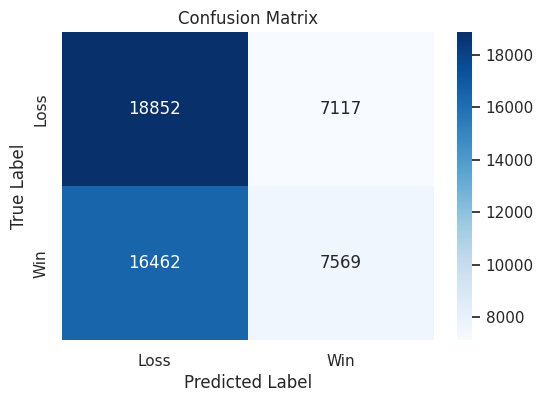

In [8]:
# make predictions on the test set
y_pred = rf_model.predict(X_test)

# calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Baseline Accuracy: {accuracy * 100:.2f}%\n")

# detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Loss', 'Win']))

# plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=['Loss', 'Win'], yticklabels=['Loss', 'Win'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 5. Feature importance

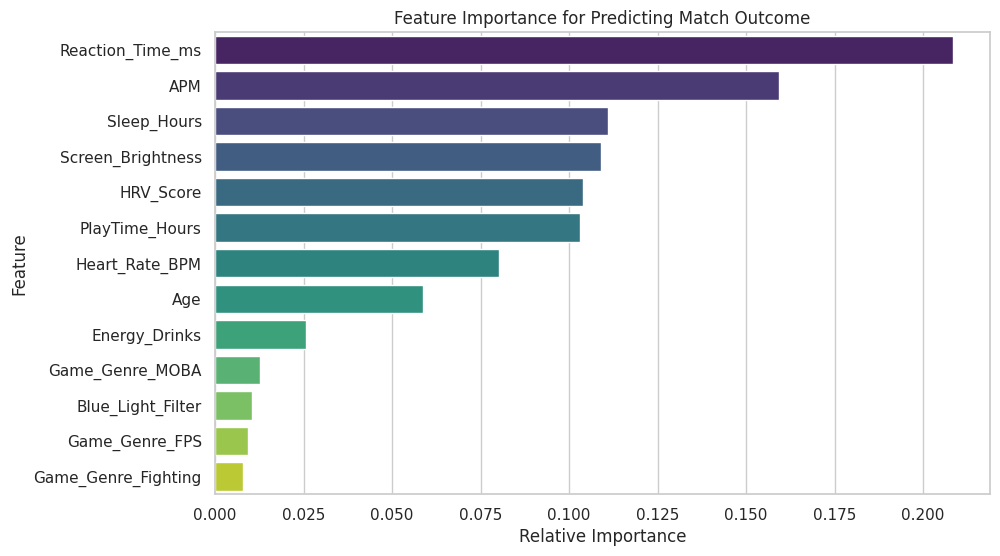

In [9]:
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance for Predicting Match Outcome')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.show()

## Conclusion 

We successfully built a baseline Random Forest model! 

**Key Takeaways:**
- The model achieved a solid baseline accuracy, showing that biological factors and in-game performance metrics absolutely hold predictive power over match outcomes.
- From the Feature Importance chart, we can see that **APM (Actions Per Minute)** and **Reaction Time** are the strongest predictors of a win.
- Secondary physiological metrics like **Heart Rate** and **HRV Score** also play a measurable role.

### Challenge:
Can you beat this baseline? Fork this notebook and try using **XGBoost**, **LightGBM**, or feature engineering (like creating an `APM / Reaction_Time` ratio) to push the accuracy even higher!

---
**If this notebook helped you get started, please leave an upvote!**